In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.metrics         import (classification_report, confusion_matrix,
                                     accuracy_score, f1_score, roc_auc_score)
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')


# load data 

In [19]:
df = pd.read_csv('df_clustered.csv')
print(f" done df_clustered.csv")
print(f"  Shape   : {df.shape}")
print(f"  Columns : {df.columns.tolist()}")

 done df_clustered.csv
  Shape   : (711168, 17)
  Columns : ['storeId', 'rating', 'sold', 'price', 'shippingCost', 'category_name', 'category_id', 'type', 'effective_price', 'discount_aggressiveness', 'value_score', 'price_vs_category_avg', 'sales_per_discount', 'price_rank_in_category', 'store_avg_sold', 'cluster_kmeans', 'strategy']


# Define features & target

In [20]:
# Features a seller knows BEFORE seeing any sales results
# No leakage — none of these contain 'sold' information
X_features = [
    'price',                    # seller sets this
    'shippingCost',             # seller sets this
    'rating',                   # product quality
    'category_id',              # product category
    'price_rank_in_category',   # position vs competitors
    'price_vs_category_avg',    # price vs category average
    'effective_price',          # real price after discount
]

X = df[X_features].copy()
y = df['strategy'].copy()

X = X.fillna(X.median())

print(f" Features : {len(X_features)}")
print(f" Shape    : {X.shape}")
print(f"\nClass distribution:")
print(y.value_counts())

 Features : 7
 Shape    : (711168, 7)

Class distribution:
strategy
Underperformer              391996
Smart Discounter            261124
Overpriced Low Performer     58048
Name: count, dtype: int64


# encode target labels 

In [21]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

joblib.dump(le, 'label_encoder.pkl')

Label encoding:
  Overpriced Low Performer → 0
  Smart Discounter → 1
  Underperformer → 2


['label_encoder.pkl']

# Train / Test split 


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size   = 0.2,
    random_state= 42,
    stratify    = y_encoded
)

print(f"\n Train set : {X_train.shape}")
print(f" Test set  : {X_test.shape}")



 Train set : (568934, 7)
 Test set  : (142234, 7)


# scale features 

In [23]:
scaler_clf     = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled  = scaler_clf.transform(X_test)

joblib.dump(scaler_clf, 'scaler_clf.pkl')
print(" Features scaled")

 Features scaled


# baseline models 

In [24]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',
        n_jobs=-1
    )
}

results = {}
print("Training baseline models")

for name, model in models.items():
    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled  if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'accuracy': acc, 'f1': f1, 'model': model}

    print(f"\n{name}:")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  F1 Score : {f1*100:.2f}%")

print("\n" + "=" * 50)
best_baseline = max(results, key=lambda x: results[x]['f1'])
print(f" Best baseline model: {best_baseline}")



Training baseline models

Logistic Regression:
  Accuracy : 91.71%
  F1 Score : 91.76%

Random Forest:
  Accuracy : 94.12%
  F1 Score : 94.14%

XGBoost:
  Accuracy : 93.77%
  F1 Score : 93.79%

 Best baseline model: Random Forest


# confusion matrix 

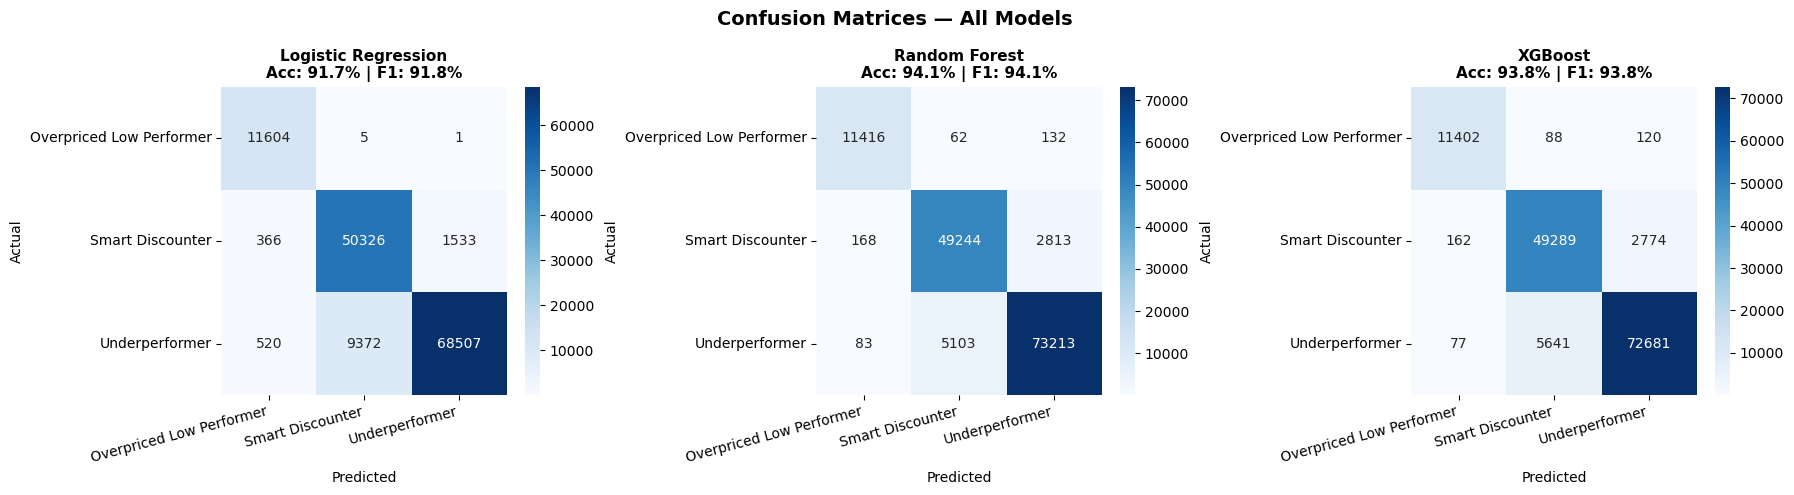


Logistic Regression — Classification Report:
--------------------------------------------------
                          precision    recall  f1-score   support

Overpriced Low Performer       0.93      1.00      0.96     11610
        Smart Discounter       0.84      0.96      0.90     52225
          Underperformer       0.98      0.87      0.92     78399

                accuracy                           0.92    142234
               macro avg       0.92      0.95      0.93    142234
            weighted avg       0.92      0.92      0.92    142234


Random Forest — Classification Report:
--------------------------------------------------
                          precision    recall  f1-score   support

Overpriced Low Performer       0.98      0.98      0.98     11610
        Smart Discounter       0.91      0.94      0.92     52225
          Underperformer       0.96      0.93      0.95     78399

                accuracy                           0.94    142234
               

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, result) in enumerate(results.items()):
    X_te   = X_test_scaled if name == 'Logistic Regression' else X_test
    y_pred = result['model'].predict(X_te)
    cm     = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                ax=axes[idx])
    axes[idx].set_title(
        f'{name}\nAcc: {result["accuracy"]*100:.1f}% | F1: {result["f1"]*100:.1f}%',
        fontsize=11, fontweight='bold'
    )
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=15, ha='right')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification reports
for name, result in results.items():
    X_te   = X_test_scaled if name == 'Logistic Regression' else X_test
    y_pred = result['model'].predict(X_te)
    print(f"\n{name} — Classification Report:")
    print("-" * 50)
    print(classification_report(y_test, y_pred, target_names=le.classes_))


# Hyperparameter tuning

In [26]:
from sklearn.model_selection import RandomizedSearchCV

# Reset index before sampling
X_train_reset = X_train.reset_index(drop=True)
y_train_reset = y_train  # already numpy array

sample_size = 100000
sample_idx  = np.random.choice(len(X_train_reset),
                                size=sample_size,
                                replace=False)
X_sample = X_train_reset.iloc[sample_idx]
y_sample = y_train_reset[sample_idx]

print(f" Using {sample_size:,} rows sample for tuning")
print("=" * 50)

rf_param_dist = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
    'max_features'     : ['sqrt', 'log2']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced',
                           random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter      = 10,
    cv          = 3,
    scoring     = 'f1_weighted',
    random_state= 42,
    n_jobs      = -1,
    verbose     = 1
)

rf_random.fit(X_sample, y_sample)

print(f"\n Best parameters found:")
for param, value in rf_random.best_params_.items():
    print(f"  {param:<20} : {value}")
print(f"\n Best CV F1 Score : {rf_random.best_score_*100:.2f}%")



 Using 100,000 rows sample for tuning
Fitting 3 folds for each of 10 candidates, totalling 30 fits

 Best parameters found:
  n_estimators         : 300
  min_samples_split    : 2
  min_samples_leaf     : 1
  max_features         : log2
  max_depth            : None

 Best CV F1 Score : 93.16%


# Train final model on full data

In [27]:
print("\n Training final model on full data...")

best_model = RandomForestClassifier(
    **rf_random.best_params_,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
best_model.fit(X_train, y_train)

joblib.dump(best_model, 'best_model.pkl')
print(f" Saved best_model.pkl")



 Training final model on full data...
 Saved best_model.pkl


# evaluate tuned model 

TUNED MODEL RESULTS
  Accuracy : 94.17%
  F1 Score : 94.19%

Improvement over baseline Random Forest:
  Accuracy : +0.05%
  F1 Score : +0.05%

Classification Report:
                          precision    recall  f1-score   support

Overpriced Low Performer       0.98      0.98      0.98     11610
        Smart Discounter       0.91      0.94      0.92     52225
          Underperformer       0.96      0.93      0.95     78399

                accuracy                           0.94    142234
               macro avg       0.95      0.95      0.95    142234
            weighted avg       0.94      0.94      0.94    142234



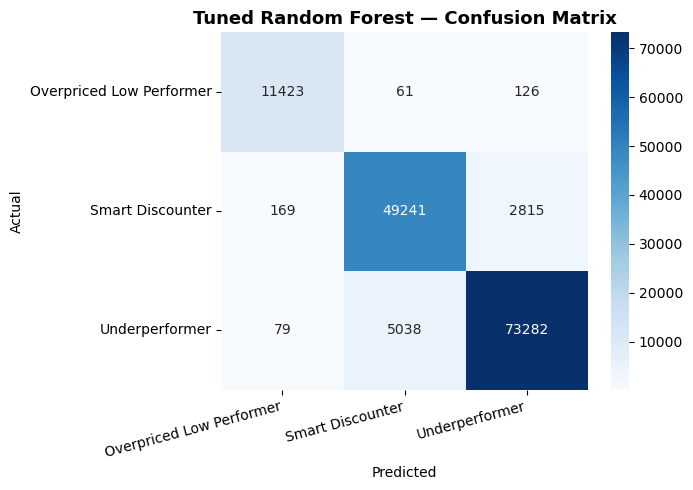

In [28]:
y_pred_tuned = best_model.predict(X_test)
acc_tuned    = accuracy_score(y_test, y_pred_tuned)
f1_tuned     = f1_score(y_test, y_pred_tuned, average='weighted')

print("=" * 50)
print("TUNED MODEL RESULTS")
print("=" * 50)
print(f"  Accuracy : {acc_tuned*100:.2f}%")
print(f"  F1 Score : {f1_tuned*100:.2f}%")
print(f"\nImprovement over baseline Random Forest:")
print(f"  Accuracy : +{(acc_tuned - results['Random Forest']['accuracy'])*100:.2f}%")
print(f"  F1 Score : +{(f1_tuned  - results['Random Forest']['f1'])*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

# Confusion matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Tuned Random Forest — Confusion Matrix',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


# cross validation 


 Cross Validation F1 Scores:
-----------------------------------
  Fold 1: 93.18%  ██████████████████████████████████████████████
  Fold 2: 93.32%  ██████████████████████████████████████████████
  Fold 3: 93.15%  ██████████████████████████████████████████████
  Fold 4: 93.50%  ██████████████████████████████████████████████
  Fold 5: 93.23%  ██████████████████████████████████████████████

  Mean  : 93.28%
  Std   : 0.12%
  Min   : 93.15%
  Max   : 93.50%

 Model is STABLE — low variance across folds


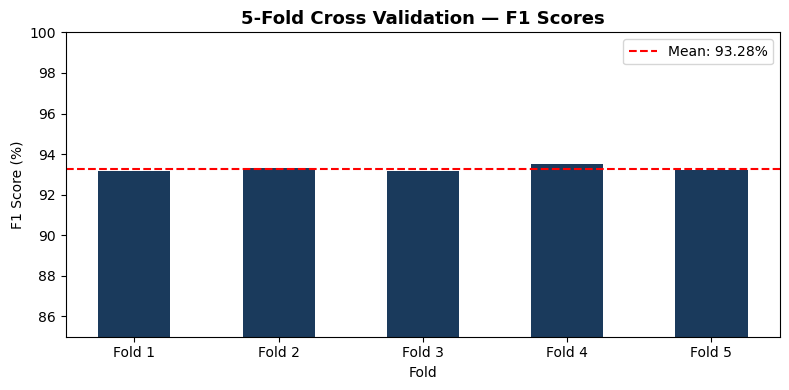

In [29]:
from sklearn.model_selection import cross_val_score

sample_size = 100000
sample_idx  = np.random.choice(len(X_train.reset_index(drop=True)),
                                size=sample_size, replace=False)
X_cv = X_train.reset_index(drop=True).iloc[sample_idx]
y_cv = y_train[sample_idx]

cv_scores = cross_val_score(
    best_model,
    X_cv, y_cv,
    cv      = 5,
    scoring = 'f1_weighted',
    n_jobs  = -1
)

print(f"\n Cross Validation F1 Scores:")
print("-" * 35)
for i, score in enumerate(cv_scores):
    bar = '█' * int(score * 50)
    print(f"  Fold {i+1}: {score*100:.2f}%  {bar}")

print(f"\n  Mean  : {cv_scores.mean()*100:.2f}%")
print(f"  Std   : {cv_scores.std()*100:.2f}%")
print(f"  Min   : {cv_scores.min()*100:.2f}%")
print(f"  Max   : {cv_scores.max()*100:.2f}%")

if cv_scores.std() < 0.02:
    print(f"\n Model is STABLE — low variance across folds")
else:
    print(f"\n  High variance — model may be overfitting")

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores * 100,
        color='#1A3A5C', edgecolor='none', width=0.5)
plt.axhline(cv_scores.mean() * 100, color='red',
            linestyle='--', linewidth=1.5,
            label=f'Mean: {cv_scores.mean()*100:.2f}%')
plt.xlabel('Fold')
plt.ylabel('F1 Score (%)')
plt.title('5-Fold Cross Validation — F1 Scores',
          fontsize=13, fontweight='bold')
plt.ylim(85, 100)
plt.xticks(range(1, 6), [f'Fold {i}' for i in range(1, 6)])
plt.legend()
plt.tight_layout()
plt.show()



# feature importance 

Feature Importance Ranking:
  1. rating                    : 0.3427  ████████████████████████████████████████████████████████████████████
  2. price                     : 0.2105  ██████████████████████████████████████████
  3. effective_price           : 0.1744  ██████████████████████████████████
  4. price_vs_category_avg     : 0.1076  █████████████████████
  5. shippingCost              : 0.0737  ██████████████
  6. price_rank_in_category    : 0.0724  ██████████████
  7. category_id               : 0.0187  ███


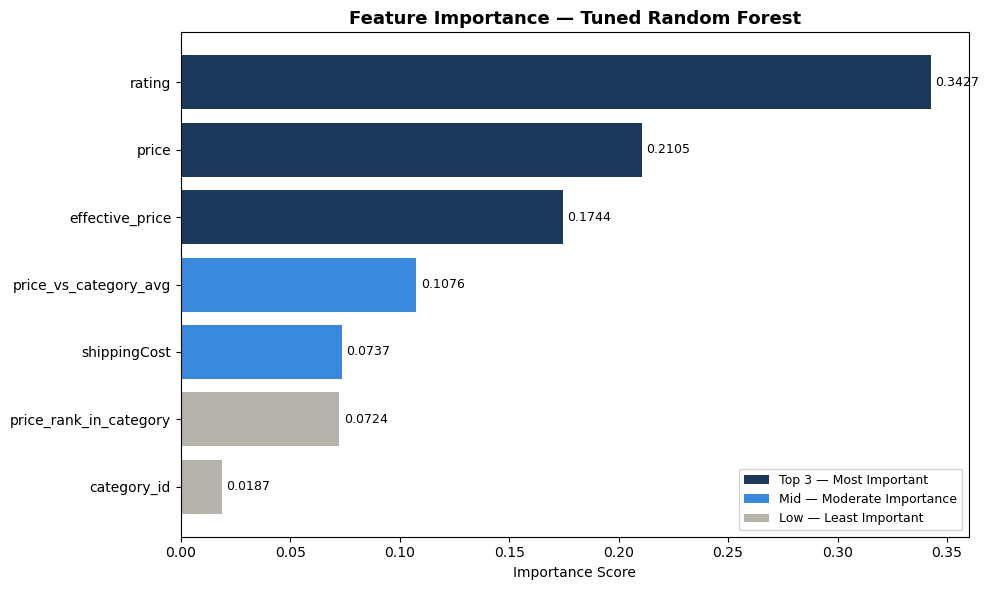

In [30]:
from matplotlib.patches import Patch

feature_importance = pd.DataFrame({
    'Feature'   : X_features,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Feature Importance Ranking:")
print("=" * 45)
for i, row in feature_importance.iterrows():
    bar = '█' * int(row['Importance'] * 200)
    print(f"  {i+1}. {row['Feature']:<25} : {row['Importance']:.4f}  {bar}")

colors = [
    '#1A3A5C' if i < 3 else
    '#378ADD' if i < 5 else
    '#B4B2A9'
    for i in range(len(feature_importance))
]

plt.figure(figsize=(10, 6))
bars = plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance'],
    color=colors, edgecolor='none'
)
for bar, val in zip(bars, feature_importance['Importance']):
    plt.text(bar.get_width() + 0.002,
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

legend_elements = [
    Patch(facecolor='#1A3A5C', label='Top 3 — Most Important'),
    Patch(facecolor='#378ADD', label='Mid — Moderate Importance'),
    Patch(facecolor='#B4B2A9', label='Low — Least Important')
]
plt.legend(handles=legend_elements, fontsize=9)
plt.title('Feature Importance — Tuned Random Forest',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



In [31]:
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler_clf, 'scaler_clf.pkl')
joblib.dump(le,         'label_encoder.pkl')

print("Models saved:")
print("   best_model.pkl      (tuned Random Forest)")
print("   scaler_clf.pkl      (StandardScaler)")
print("   label_encoder.pkl   (LabelEncoder)")

# Save results summary
results_summary = pd.DataFrame({
    'Model'    : list(results.keys()),
    'Accuracy' : [r['accuracy']*100 for r in results.values()],
    'F1_Score' : [r['f1']*100       for r in results.values()]
}).round(2)

tuned_row = pd.DataFrame([{
    'Model'    : 'Random Forest (Tuned)',
    'Accuracy' : acc_tuned * 100,
    'F1_Score' : f1_tuned  * 100
}])
results_summary = pd.concat([results_summary, tuned_row], ignore_index=True)
results_summary.to_csv('model_results.csv', index=False)

print("\n Results saved:")
print("  → model_results.csv")
print("\nFinal Results Summary:")
print("=" * 45)
print(results_summary.to_string(index=False))

print(f"\n  Best Model     : Tuned Random Forest")
print(f"  Accuracy       : {acc_tuned*100:.2f}%")
print(f"  F1 Score       : {f1_tuned*100:.2f}%")
print(f"  CV Mean F1     : {cv_scores.mean()*100:.2f}%")
print(f"  CV Std         : {cv_scores.std()*100:.2f}%")
print("done")


Models saved:
   best_model.pkl      (tuned Random Forest)
   scaler_clf.pkl      (StandardScaler)
   label_encoder.pkl   (LabelEncoder)

 Results saved:
  → model_results.csv

Final Results Summary:
                Model  Accuracy  F1_Score
  Logistic Regression 91.710000 91.760000
        Random Forest 94.120000 94.140000
              XGBoost 93.770000 93.790000
Random Forest (Tuned) 94.172983 94.189913

  Best Model     : Tuned Random Forest
  Accuracy       : 94.17%
  F1 Score       : 94.19%
  CV Mean F1     : 93.28%
  CV Std         : 0.12%
done
